In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset
import os
from sklearn.metrics import accuracy_score
import torchvision
import zipfile
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm
import seaborn as sns

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
'''
NOTE: CIFAR10 class codes
{
  0: "airplane",
  1: "automobile",
  2: "bird",
  3: "cat",
  4: "deer",
  5: "dog",
  6: "frog",
  7: "horse",
  8: "ship",
  9: "truck"
}
'''

'\nNOTE: CIFAR10 class codes\n{\n  0: "airplane",\n  1: "automobile",\n  2: "bird",\n  3: "cat",\n  4: "deer",\n  5: "dog",\n  6: "frog",\n  7: "horse",\n  8: "ship",\n  9: "truck"\n}\n'

# General

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        #self.bn1 = nn.LayerNorm([32, 32, 32])
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        #self.bn2 = nn.LayerNorm([64, 16, 16])
        self.fc1 = nn.Linear(64*8*8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = x.view(-1, x.shape[1]*x.shape[2]*x.shape[3])
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# def create_model(device="cpu"):
#     return SimpleCNN().to(device)

def create_model(device="cpu"):
    model = torchvision.models.resnet18(num_classes=10)

    # Modifica conv1
    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    # Rimuovi maxpool
    model.maxpool = nn.Identity()
    model = model.to(device)
    return model

def train_model(model, dl, lr, momentum, epochs, device="cpu", inplace=False):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()
    
    model.to(device)
    model.train()
    
    for e in range(epochs):
        for data, target in dl:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            pred = model(data)
            
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

    return model


# Libraries

## Utils

In [6]:
class Client:
    def __init__(self, id, ds, model, dl = None, data_idxs = None):
        self.id = id
        self.ds = ds
        self.dl = dl
        self.data_idxs = data_idxs
        self.model = model

def stable_softmax(logits):
    # Numerically stable softmax
    predictions = torch.exp(logits - torch.max(logits, dim=-1, keepdims=True).values)
    predictions = predictions / torch.sum(predictions, dim=-1, keepdims=True)
    return predictions

def predict_labels(model, dl, device="cpu"):
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            logits = model(imgs)
            predictions = logits.argmax(dim=1)
            y_pred.append(predictions.cpu())
            y_true.append(lbls.cpu())
    
    return torch.cat(y_true), torch.cat(y_pred)

def predict_proba(model, ds, device="cpu", use_stable_softmax=False, return_labels = False):
    model.eval()
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    probs = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            if use_stable_softmax:
                p = stable_softmax(logits)
                probs.extend(p)
            else:
                probs.extend(F.softmax(logits, dim=1))

            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(probs), torch.stack(labels)
    else:
        return torch.stack(probs)

def compute_logits(model, ds, device="cpu", return_labels = False):
    model.eval()
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    logits = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits.extend(model(imgs))
            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(logits), torch.stack(labels)
    else:
        return torch.stack(logits)

def predict_phi_scores(model, ds, device="cpu", return_labels=False):
    probs, labels = predict_proba(model, ds, device=device, use_stable_softmax=True, return_labels=True)
    probs, labels = probs.cpu().numpy(), labels.cpu().numpy()
    
    # Compute probability of the true class and the probability of all other classes
    # np.arange(predictions.shape[0]) is needed to correctly indexing of numpy array
    p_true = probs[np.arange(probs.shape[0]), labels]
    probs[np.arange(probs.shape[0]), labels] = 0
    p_wrong = np.sum(probs, axis=-1)

    # Compute phi
    eps = 1e-45
    phis = np.log(p_true + eps) - np.log(p_wrong + eps)
    
    if return_labels:
        return phis, labels
    else:
        return phis

def predict_losses(model, ds, device="cpu", return_labels=False):
    logits, labels = compute_logits(model, ds, device=device, return_labels=True)  
    losses = F.cross_entropy(logits, labels, reduction="none")

    losses, labels = losses.cpu().numpy(), labels.cpu().numpy()

    if return_labels:
        return losses, labels
    else:
        return losses



def get_labels(ds):
    dl = DataLoader(ds, batch_size=1024)
    labels = []
    for _, lbls in dl:
        labels.extend(lbls)
    
    return torch.tensor(labels)


def compute_accuracy(model, dl, device="cpu"):
    y_true, y_pred = predict_labels(model, dl, device=device)
    return accuracy_score(y_true=y_true, y_pred=y_pred)

def compute_error_rate(model, dl, device="cpu"):
    return 1 - compute_accuracy(model, dl, device=device)


def save_model(model, name, verbose=True, device="cuda"):
    if device=="cuda":
        torch.save(model.state_dict(), f"{name}.pth")
        if verbose:
            print(f"Model params saved in '{name}.pth'")
    
    model = model.to("cpu")
    torch.save(model.state_dict(), f"{name}_cpu.pth")
    if verbose:
        print(f"Model params saved in '{name}_cpu.pth'")
    
    model.to(device)

def load_model(model, name, verbose=True, device="cuda"):
    if device=="cpu":
        path = f"{name}_cpu.pth"
    else:
        path = f"{name}.pth"
    model.load_state_dict(torch.load(path))
    if verbose:
        print(f"Model loaded from '{path}'")

def save_array(arr, name, verbose=True):
    np.save(f"{name}.npy", arr)
    if verbose:
        print(f"Array saved in '{name}.npy'")

def load_array(name, verbose=True):
    arr = np.load(f"{name}.npy")
    if verbose:
        print(f"Array loaded from '{name}.npy'")
    return arr



def roc_chart(true_memberships, scores, axis: plt.Axes, color="darkorange", title="", log_scale=False):

    fpr, tpr, roc = roc_curve(true_memberships, scores)

    axis.plot(fpr, tpr, color=color, lw=1, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
    axis.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    if log_scale:
        axis.set_xlim([1e-5, 1.0])
        axis.set_ylim([1e-5, 1.0])
        axis.set_xscale("log")
        axis.set_yscale("log")
    else:
        axis.set_xlim([0, 1.0])
        axis.set_ylim([0, 1.0])
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    if title!= "":
        axis.set_title(title)
    else:
        axis.set_title('ROC')
    axis.legend(loc="lower right")



def get_activation(name, dict, detach_output=True):
    def hook(model, input, output):
        if detach_output:
            dict[name] = output.detach()
        else:
            dict[name] = output
    return hook

def get_activations(model, img, detach_output=True):
    handles = []
    activations = {}

    for name, layer in model.named_modules():
        if name != "":
            handles.append(layer.register_forward_hook(get_activation(name, activations, detach_output=detach_output)))
    
    model(img)

    for handle in handles:
        handle.remove() 

    return activations


def get_distance_between_models(model1, model2):
    with torch.no_grad():
        model1_flattened = nn.utils.parameters_to_vector(model1.parameters())
        model2_flattened = nn.utils.parameters_to_vector(model2.parameters())
        distance = torch.square(torch.norm(model1_flattened - model2_flattened))
    return distance



def plot_hists(stats_red, stst_blue, axis, label_red="red", label_blue="blue", title=""):
    axis.set_title(title)
    
    bins = np.histogram_bin_edges(np.concatenate([stats_red, stst_blue]), bins='auto')
    sns.histplot(stats_red, ax=axis, bins=bins, color="red", alpha=0.5, label=label_red)
    sns.histplot(stst_blue, ax=axis, bins=bins, color="blue", alpha=0.5, label=label_blue)

    axis.legend()


# Dataset Loading

In [7]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

N_CLIENTS, CLIENT_SIZE = 10, 1000

BATCH_SIZE = 32
UNLEARNING_INTERVAL = 1
CLIENT_ID_TO_UNLEARN = 0
CLIENT_IDS_TO_UNLEARN = [CLIENT_ID_TO_UNLEARN]

IN_CH = 3
IN_W, IN_H = 32, 32
CLASSES = 10

NORMALIZATION_MEANS, NORMALIZATION_STDS = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)


# Load DS
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(NORMALIZATION_MEANS, NORMALIZATION_STDS)])
ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
ds_test = CIFAR10(root="./data", train=False, download=True, transform=transform)

test_dl = DataLoader(ds_test, batch_size=256, shuffle=False)

# Create clients
clients: list[Client] = []
idxs = np.array_split(np.arange(N_CLIENTS*CLIENT_SIZE), N_CLIENTS)

for i in range(N_CLIENTS):
    ds = Subset(ds_train, indices=idxs[i])
    dl =  DataLoader(ds, batch_size=BATCH_SIZE)
    clients.append(Client(i, ds, create_model(device=device), dl=dl, data_idxs=idxs[i]))

#not_used_ds_train = Subset(ds_train, np.arange(N_CLIENTS*CLIENT_SIZE + CLIENT_SIZE, len(ds_train)))

retained_clients = [c for c in clients if c.id not in CLIENT_IDS_TO_UNLEARN]
unlearned_clients = [c for c in clients if c.id in CLIENT_IDS_TO_UNLEARN]

retained_ds = ConcatDataset([c.ds for c in retained_clients])
unlearned_ds = ConcatDataset([c.ds for c in unlearned_clients])

retained_dl = DataLoader(retained_ds, batch_size=128, shuffle=False)
unlearned_dl = DataLoader(unlearned_ds, batch_size=128, shuffle=False)

print(f"N clients: {N_CLIENTS}")
print(f"N clients to unlearn: {len(unlearned_clients)}")
print(f"N clients remaining: {len(retained_clients)}")
print(f"Samples to be unlearned: {len(unlearned_ds)}")
print(f"Samples remaining: {len(retained_ds)}")


100%|██████████| 170M/170M [00:03<00:00, 48.4MB/s] 


N clients: 10
N clients to unlearn: 1
N clients remaining: 9
Samples to be unlearned: 1000
Samples remaining: 9000


# Federated Learning/Unlearning area

## Lib

In [8]:
import copy
from torch.utils.data import ConcatDataset, DataLoader
from typing import Any

###################
# CLASSES
###################

class RoundLog:
    def __init__(self, round_, global_model, client_updates: dict[int, Any]):
        self.round = round_
        self.global_model = global_model
        self.client_updates = client_updates
    
    def get_partecipating_client_ids(self):
        return self.client_updates.keys()


###################
# FEDAVG
###################

def fedavg_from_state_dict(global_model, client_dicts, client_weights):
    global_model = copy.deepcopy(global_model)

    avg = {}
    total_weights = sum(client_weights)
    for key in client_dicts[0].keys():
        avg[key] = sum([client_weights[i]*cd[key] for i, cd in enumerate(client_dicts)]) / total_weights

    global_model.load_state_dict(avg)
    return global_model

def fedavg_with_weights(clients, client_weights):
    client_dicts = [c.model.state_dict() for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg_from_models(client_models, client_weights):
    client_dicts = [model.state_dict() for model in client_models]
    return fedavg_from_state_dict(client_models[0], client_dicts, client_weights)

def fedavg_data_based_weights(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [len(c.ds) for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [1 for _ in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def train_client(train_fn, global_model, client, epochs, device="cpu", inplace=False):
    client_model = copy.deepcopy(global_model)

    train_fn(client_model, client.dl, epochs, device=device)

    if inplace:
        client.model = client_model

    return client_model

def train_fedavg(init_global_model, clients, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):

    global_model = init_global_model
    if verbose:
        train_ds = ConcatDataset([c.ds for c in clients])
        train_dl = DataLoader(train_ds, batch_size=256)

    if return_log:
        logs = []
        global_model = global_model.cpu()
        logs.append(RoundLog(0, copy.deepcopy(global_model), {}))
        global_model = global_model.to(device)
    
    for r in range(1, rounds+1):
        client_updates = {}
        for client in clients:
            client_model = train_client(train_fn, global_model, client, epochs, device=device, inplace=False)
            if return_log:
                client_model = client_model.cpu()
                client_updates[client.id] = copy.deepcopy(client_model)
                client_model = client_model.to(device)
            client.model = client_model

        global_model = fedavg(clients)
        if return_log:
            global_model = global_model.cpu()
            logs.append(RoundLog(1, copy.deepcopy(global_model), client_updates))
            global_model = global_model.to(device)

        if verbose:
            #global_model = global_model.to(device)
            train_acc = compute_accuracy(global_model, train_dl, device=device)

            eval_acc = -1
            if eval_dl != None:
                eval_acc = compute_accuracy(global_model, eval_dl, device=device)
            
            print(f"Ended training for round {r}/{rounds}, train acc = {train_acc:.4f}, eval acc = {eval_acc:.4f}")

    if return_log:
        return global_model, logs
    else:
        return global_model


def fed_retrain(init_global_model, clients, client_ids_to_unlearn, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):
    remaining_clients = [c for c in clients if c.id not in client_ids_to_unlearn]
    print(f"Training on {len(remaining_clients)} out of {len(clients)}, ids: {[c.id for c in remaining_clients]}")
    return train_fedavg(init_global_model, remaining_clients, rounds, epochs, train_fn, device=device, return_log=return_log, verbose=verbose, eval_dl = eval_dl)
###################


In [9]:

def gradient_ascent_unlearning(global_model, create_model_fn, clients, unl_client_model, client_id_to_unlearn, num_local_epochs_unlearn = 5, ulr = 0.001, 
              distance_threshold = 2.2, clip_grad = 5, num_updates_in_epoch = None, device="cpu", eval_dl=None, verbose=False):

    retained_clients = [c for c in clients if c.id != client_id_to_unlearn]
    unleanred_client = [c for c in clients if c.id == client_id_to_unlearn][0]

    unleanred_dl = unleanred_client.dl

    if verbose:
        retained_ds = ConcatDataset([c.ds for c in retained_clients])
        retained_dl = DataLoader(retained_ds, batch_size=256)
        

    global_model = copy.deepcopy(global_model).cpu()
    unl_client_model = copy.deepcopy(unl_client_model).cpu()

    #compute reference model
    #w_ref = N/(N-1)w^T - 1/(N-1)w^{T-1}_i = \sum{i \ne j}w_j^{T-1}
    model_ref_vec = len(clients) / (len(clients) - 1) * nn.utils.parameters_to_vector(global_model.parameters()) \
                                - 1 / (len(clients) - 1) * nn.utils.parameters_to_vector(unl_client_model.parameters())

    #compute threshold
    model_ref = create_model_fn().cpu()
    nn.utils.vector_to_parameters(model_ref_vec, model_ref.parameters())

    if verbose:
        model_ref.to(device)
        train_acc = compute_accuracy(model_ref, retained_dl, device=device)
        unleanred_acc = compute_accuracy(model_ref, unleanred_dl, device=device)

        eval_acc = -1
        if eval_dl != None:    
            eval_acc = compute_accuracy(model_ref, eval_dl, device=device)
        
        model_ref.cpu()
        print(f"Reference Model, acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")
    

    dist_ref_random_lst = []
    random_model = create_model_fn().cpu()
    for _ in range(10):
        dist_ref_random_lst.append(get_distance_between_models(model_ref, random_model))    

    threshold = np.mean(dist_ref_random_lst) / 3


    ###############################################################
    #### Unlearning
    ###############################################################
    model_ref = model_ref.to(device)
    unl_client_model = unl_client_model.to(device)

    unlearned_model = copy.deepcopy(model_ref).to(device)
    
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.SGD(unlearned_model.parameters(), lr=ulr, momentum=0.9) 

    flag = False
    for epoch in range(num_local_epochs_unlearn):
        if flag:
            break
        for batch_id, (images, labels) in enumerate(unleanred_dl):
            unlearned_model.train()
            images, labels = images.to(device), labels.to(device)

            opt.zero_grad()

            output = unlearned_model(images)
            loss = criterion(output, labels)
            loss_joint = -loss # negate the loss for gradient ascent
            loss_joint.backward()
            
            if clip_grad > 0:
                torch.nn.utils.clip_grad_norm_(unlearned_model.parameters(), clip_grad)

            opt.step()

            with torch.no_grad():
                distance = get_distance_between_models(unlearned_model, model_ref)
                if distance > threshold:
                    dist_vec = nn.utils.parameters_to_vector(unlearned_model.parameters()) - nn.utils.parameters_to_vector(model_ref.parameters())
                    dist_vec = dist_vec/torch.norm(dist_vec)*np.sqrt(threshold)
                    proj_vec = nn.utils.parameters_to_vector(model_ref.parameters()) + dist_vec
                    nn.utils.vector_to_parameters(proj_vec, unlearned_model.parameters())

            distance_ref_unlearned_cleint = get_distance_between_models(unlearned_model, unl_client_model)
            
            if distance_ref_unlearned_cleint > distance_threshold:
                flag = True
                break

            if num_updates_in_epoch is not None and batch_id >= num_updates_in_epoch:
                break

        if verbose:

            train_acc = compute_accuracy(unlearned_model, retained_dl, device=device)
            unleanred_acc = compute_accuracy(unlearned_model, unleanred_dl, device=device)

            eval_acc = -1
            if eval_dl != None:    
                eval_acc = compute_accuracy(unlearned_model, eval_dl, device=device)
            
            print('Distance from the unlearned model to unlearned client:', distance_ref_unlearned_cleint.item())
            print(f"Ended Gradient Ascent for epoch {epoch+1}/{num_local_epochs_unlearn}, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

            
    ####################################################################                           

    return unlearned_model

## Training

### FedAvg

In [10]:
ROUNDS, EPOCHS = 15, 5
LR = 0.01
MOMENTUM = 0.9

# Training function
train_fn = lambda model, dl, epochs, device, inplace=False: train_model(model, dl, LR, MOMENTUM, epochs, device, inplace=inplace)

# Global model
init_global_model = create_model(device=device)

In [11]:
# FedAvg
global_model = train_fedavg(copy.deepcopy(init_global_model), clients, ROUNDS, EPOCHS, train_fn, device=device, 
                                  return_log=False, eval_dl=test_dl, verbose=True)

train_acc = compute_accuracy(global_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(global_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(global_model, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

save_model(global_model, "fedavg_resnet18_10x1000", verbose=True, device=device)

unlearned_client_model = clients[CLIENT_ID_TO_UNLEARN].model
save_model(unlearned_client_model, "unlearned_client_update_resnet18_10x1000", verbose=True, device=device)

Ended training for round 1/15, train acc = 0.1333, eval acc = 0.1323
Ended training for round 2/15, train acc = 0.2378, eval acc = 0.2324
Ended training for round 3/15, train acc = 0.4148, eval acc = 0.3503
Ended training for round 4/15, train acc = 0.5648, eval acc = 0.4423
Ended training for round 5/15, train acc = 0.6799, eval acc = 0.4832
Ended training for round 6/15, train acc = 0.7478, eval acc = 0.4998
Ended training for round 7/15, train acc = 0.8766, eval acc = 0.5503
Ended training for round 8/15, train acc = 0.9584, eval acc = 0.5641
Ended training for round 9/15, train acc = 0.9949, eval acc = 0.5695
Ended training for round 10/15, train acc = 0.9995, eval acc = 0.5685
Ended training for round 11/15, train acc = 0.9996, eval acc = 0.5692
Ended training for round 12/15, train acc = 0.9997, eval acc = 0.5695
Ended training for round 13/15, train acc = 0.9997, eval acc = 0.5687
Ended training for round 14/15, train acc = 0.9997, eval acc = 0.5680
Ended training for round 15/1

In [9]:
FEDAVG_MODEL_PATH = "/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/fedavg_resnet18_10x1000"
global_model = create_model(device=device)
load_model(global_model, FEDAVG_MODEL_PATH, verbose=True, device=device)

train_acc = compute_accuracy(global_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(global_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(global_model, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

Model loaded from '/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/fedavg_resnet18_10x1000.pth'
Model performance, train acc = 0.9990, unlearned acc = 0.9970, eval acc = 0.6009


In [10]:
UNLEARNING_CLIENT_MODEL_PATH = "/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/unlearned_client_update_resnet18_10x1000"
unlearned_client_model = create_model(device=device)
load_model(unlearned_client_model, UNLEARNING_CLIENT_MODEL_PATH, verbose=True, device=device)

train_acc = compute_accuracy(unlearned_client_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(unlearned_client_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(unlearned_client_model, test_dl, device=device)
clients[CLIENT_ID_TO_UNLEARN].model = unlearned_client_model

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

Model loaded from '/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/unlearned_client_update_resnet18_10x1000.pth'
Model performance, train acc = 0.9950, unlearned acc = 0.9990, eval acc = 0.5976


### FedRetrain

In [12]:
# FedRetrain
retrained_model = fed_retrain(copy.deepcopy(init_global_model), clients, CLIENT_IDS_TO_UNLEARN, ROUNDS, EPOCHS, train_fn, device=device, 
                                  return_log=False, eval_dl=test_dl, verbose=True)

train_acc = compute_accuracy(retrained_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(retrained_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(retrained_model, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

save_model(retrained_model, "fedretrain_resnet18_10x1000", verbose=True, device=device)

Training on 9 out of 10, ids: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Ended training for round 1/15, train acc = 0.1293, eval acc = 0.1322
Ended training for round 2/15, train acc = 0.2249, eval acc = 0.2199
Ended training for round 3/15, train acc = 0.4188, eval acc = 0.3551
Ended training for round 4/15, train acc = 0.6109, eval acc = 0.4541
Ended training for round 5/15, train acc = 0.7059, eval acc = 0.4827
Ended training for round 6/15, train acc = 0.8000, eval acc = 0.5150
Ended training for round 7/15, train acc = 0.8980, eval acc = 0.5377
Ended training for round 8/15, train acc = 0.9674, eval acc = 0.5463
Ended training for round 9/15, train acc = 0.9971, eval acc = 0.5601
Ended training for round 10/15, train acc = 0.9992, eval acc = 0.5613
Ended training for round 11/15, train acc = 0.9993, eval acc = 0.5615
Ended training for round 12/15, train acc = 0.9994, eval acc = 0.5606
Ended training for round 13/15, train acc = 0.9998, eval acc = 0.5610
Ended training for round 14/15, train acc

In [11]:
FEDRETRAIN_MODEL_PATH = "/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/fedretrain_resnet18_10x1000"
retrained_model = create_model(device=device)
load_model(retrained_model, FEDRETRAIN_MODEL_PATH, verbose=True, device=device)

train_acc = compute_accuracy(retrained_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(retrained_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(retrained_model, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

Model loaded from '/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/fedretrain_resnet18_10x1000.pth'
Model performance, train acc = 0.9988, unlearned acc = 0.5800, eval acc = 0.5924


In [67]:
# FedRetrain
check_retrained_model = fed_retrain(copy.deepcopy(init_global_model), clients, CLIENT_IDS_TO_UNLEARN, ROUNDS, EPOCHS, train_fn, device=device, 
                                  return_log=False, eval_dl=test_dl, verbose=True)

train_acc = compute_accuracy(check_retrained_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(check_retrained_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(check_retrained_model, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

save_model(check_retrained_model, "check_fedretrain_resnet18_10x1000", verbose=True, device=device)

Training on 9 out of 10, ids: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Ended training for round 1/15, train acc = 0.1022, eval acc = 0.1015
Ended training for round 2/15, train acc = 0.1611, eval acc = 0.1615
Ended training for round 3/15, train acc = 0.3340, eval acc = 0.3094
Ended training for round 4/15, train acc = 0.5116, eval acc = 0.4317
Ended training for round 5/15, train acc = 0.6390, eval acc = 0.4930
Ended training for round 6/15, train acc = 0.7256, eval acc = 0.5243
Ended training for round 7/15, train acc = 0.7992, eval acc = 0.5488
Ended training for round 8/15, train acc = 0.8543, eval acc = 0.5591
Ended training for round 9/15, train acc = 0.8886, eval acc = 0.5563
Ended training for round 10/15, train acc = 0.9579, eval acc = 0.5857
Ended training for round 11/15, train acc = 0.9893, eval acc = 0.5851
Ended training for round 12/15, train acc = 0.9960, eval acc = 0.5867
Ended training for round 13/15, train acc = 0.9977, eval acc = 0.5880
Ended training for round 14/15, train acc

### GA

In [13]:
# Unlearning
create_model_fn = lambda: create_model(device=device)
ga_unl_global_model = gradient_ascent_unlearning(copy.deepcopy(global_model), create_model_fn, clients, unlearned_client_model, CLIENT_ID_TO_UNLEARN, 
                                                          num_local_epochs_unlearn = 10, ulr = 0.005, distance_threshold = 2.2, 
                                                          clip_grad = 1, num_updates_in_epoch=None, device=device, eval_dl=test_dl, verbose=True)

Reference Model, acc = 0.1780, unlearned acc = 0.2010, eval acc = 0.1760
Distance from the unlearned model to unlearned client: 0.03057912550866604
Ended Gradient Ascent for epoch 1/10, train acc = 0.9998, unlearned acc = 0.9980, eval acc = 0.5654
Distance from the unlearned model to unlearned client: 0.09762784838676453
Ended Gradient Ascent for epoch 2/10, train acc = 0.9992, unlearned acc = 0.9680, eval acc = 0.5597
Distance from the unlearned model to unlearned client: 0.34965988993644714
Ended Gradient Ascent for epoch 3/10, train acc = 0.9521, unlearned acc = 0.8620, eval acc = 0.5224
Distance from the unlearned model to unlearned client: 0.9555881023406982
Ended Gradient Ascent for epoch 4/10, train acc = 0.7353, unlearned acc = 0.6540, eval acc = 0.4202
Distance from the unlearned model to unlearned client: 2.219714879989624
Ended Gradient Ascent for epoch 5/10, train acc = 0.4271, unlearned acc = 0.3540, eval acc = 0.2807


In [14]:
# Recovery rounds
ga_unl_global_model_recovered = train_fedavg(copy.deepcopy(ga_unl_global_model), retained_clients, 7, 5, train_fn, 
                                                      device=device, return_log=False, eval_dl=test_dl, verbose=True)

train_acc = compute_accuracy(ga_unl_global_model_recovered, retained_dl, device=device)
unleanred_acc = compute_accuracy(ga_unl_global_model_recovered, unlearned_dl, device=device)
eval_acc = compute_accuracy(ga_unl_global_model_recovered, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

save_model(ga_unl_global_model_recovered, "ga_resnet18_10x1000", verbose=True, device=device)

Ended training for round 1/7, train acc = 0.7103, eval acc = 0.4618
Ended training for round 2/7, train acc = 0.9911, eval acc = 0.5661
Ended training for round 3/7, train acc = 0.9990, eval acc = 0.5668
Ended training for round 4/7, train acc = 1.0000, eval acc = 0.5659
Ended training for round 5/7, train acc = 1.0000, eval acc = 0.5657
Ended training for round 6/7, train acc = 1.0000, eval acc = 0.5656
Ended training for round 7/7, train acc = 1.0000, eval acc = 0.5649
Model performance, train acc = 1.0000, unlearned acc = 0.8510, eval acc = 0.5649
Model params saved in 'ga_resnet18_10x1000.pth'
Model params saved in 'ga_resnet18_10x1000_cpu.pth'


In [13]:
GA_MODEL_PATH = "/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/ga_resnet18_10x1000"
ga_unl_global_model_recovered = create_model(device=device)
load_model(ga_unl_global_model_recovered, GA_MODEL_PATH, verbose=True, device=device)

train_acc = compute_accuracy(ga_unl_global_model_recovered, retained_dl, device=device)
unleanred_acc = compute_accuracy(ga_unl_global_model_recovered, unlearned_dl, device=device)
eval_acc = compute_accuracy(ga_unl_global_model_recovered, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

Model loaded from '/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/ga_resnet18_10x1000.pth'
Model performance, train acc = 0.9994, unlearned acc = 0.8380, eval acc = 0.6052


### NoT

In [15]:
def not_unlearning(model, layer_indicies=[0]):
    with torch.no_grad():
        for layer_indx, param in enumerate(model.parameters()):
            if layer_indx in layer_indicies:
                param.data =-1 * param.data
    return model

not_unl_model = not_unlearning(copy.deepcopy(global_model))

train_acc = compute_accuracy(not_unl_model, retained_dl, device=device)
unleanred_acc = compute_accuracy(not_unl_model, unlearned_dl, device=device)
eval_acc = compute_accuracy(not_unl_model, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

Model performance, train acc = 0.1680, unlearned acc = 0.1640, eval acc = 0.1708


In [16]:
# Recovery rounds
not_unl_model_recovered = train_fedavg(copy.deepcopy(not_unl_model), retained_clients, 7, 5, train_fn, 
                                                      device=device, return_log=False, eval_dl=test_dl, verbose=True)

train_acc = compute_accuracy(not_unl_model_recovered, retained_dl, device=device)
unleanred_acc = compute_accuracy(not_unl_model_recovered, unlearned_dl, device=device)
eval_acc = compute_accuracy(not_unl_model_recovered, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

save_model(not_unl_model_recovered, "not_resnet18_10x1000", verbose=True, device=device)

Ended training for round 1/7, train acc = 0.3297, eval acc = 0.3005
Ended training for round 2/7, train acc = 0.7342, eval acc = 0.5377
Ended training for round 3/7, train acc = 0.8477, eval acc = 0.5596
Ended training for round 4/7, train acc = 0.9349, eval acc = 0.5749
Ended training for round 5/7, train acc = 0.9907, eval acc = 0.5823
Ended training for round 6/7, train acc = 0.9998, eval acc = 0.5832
Ended training for round 7/7, train acc = 1.0000, eval acc = 0.5836
Model performance, train acc = 1.0000, unlearned acc = 0.5800, eval acc = 0.5836
Model params saved in 'not_resnet18_10x1000.pth'
Model params saved in 'not_resnet18_10x1000_cpu.pth'


In [14]:
NOT_MODEL_PATH = "/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/not_resnet18_10x1000"
not_unl_model_recovered = create_model(device=device)
load_model(not_unl_model_recovered, NOT_MODEL_PATH, verbose=True, device=device)

train_acc = compute_accuracy(not_unl_model_recovered, retained_dl, device=device)
unleanred_acc = compute_accuracy(not_unl_model_recovered, unlearned_dl, device=device)
eval_acc = compute_accuracy(not_unl_model_recovered, test_dl, device=device)

print(f"Model performance, train acc = {train_acc:.4f}, unlearned acc = {unleanred_acc:.4f}, eval acc = {eval_acc:.4f}")

Model loaded from '/kaggle/input/datasets/lorenzozoccadelli/saved-models/models/not_resnet18_10x1000.pth'
Model performance, train acc = 0.9962, unlearned acc = 0.6110, eval acc = 0.6190


# Adapter

In [17]:
global_model = copy.deepcopy(global_model)
retrained_model = copy.deepcopy(retrained_model)
ga_unlearned_model = copy.deepcopy(ga_unl_global_model_recovered)
not_unlearned_model = copy.deepcopy(not_unl_model_recovered)

full_members_dl = unlearned_dl
full_non_members_dl = DataLoader(ds_test, batch_size=128, shuffle=True)

def shadow_model_training_fn(model, ds):
    new_model = train_model(model, DataLoader(ds, batch_size=64), 0.005, 0.9, 30, device=device)
    model.load_state_dict(new_model.state_dict())
    train_acc = compute_accuracy(model, DataLoader(ds, batch_size=128), device=device)
    print(f"Shadow model accuracy on attack ds: {train_acc:.4f}")

def feature_extractor(model, imgs):
    activations = get_activations(model, imgs)
    features = activations["avgpool"].squeeze()
    #features = features.view(-1, features.shape[1]*features.shape[2]*features.shape[3])
    return features.cpu()

# My tests

## Preparation of attack dataset

In [18]:
n_unlearned_samples = len(torch.cat([x for x, _ in full_members_dl]))
n_non_memebrs_samples = len(torch.cat([x for x, _ in full_non_members_dl]))
n_samples = np.min([n_unlearned_samples, n_non_memebrs_samples])

dl_members = DataLoader(Subset(full_members_dl.dataset, np.arange(n_samples)), batch_size=64, shuffle=False)
dl_non_members = DataLoader(Subset(full_non_members_dl.dataset, np.arange(n_samples)), batch_size=64, shuffle=False)

X_m = torch.cat([x for x, _ in dl_members])
y_m = torch.cat([y for _, y in dl_members])

X_nm = torch.cat([x for x, _ in dl_non_members])
y_nm = torch.cat([y for _, y in dl_non_members])

att_imgs, att_labels = torch.cat([X_m, X_nm]), torch.cat([y_m, y_nm])
ds_att = TensorDataset(att_imgs, att_labels)

target_model_memberships = np.full(len(ds_att), False)
target_model_memberships[:len(X_m)] = True

create_model_fn = lambda: create_model(device=device)

# Here we have ds_att and corresponding target_model_memberships

## Feature inversion

In [83]:
img = torch.zeros((1, 3, 224, 224), device=device)
global_model.to(device)
activations = get_activations(global_model, img)
print(activations.keys())

dict_keys(['conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.1', 'layer1', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0.downsample.0', 'layer2.0.downsample.1', 'layer2.0.downsample', 'layer2.0', 'layer2.1.conv1', 'layer2.1.bn1', 'layer2.1.relu', 'layer2.1.conv2', 'layer2.1.bn2', 'layer2.1', 'layer2', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0.downsample.0', 'layer3.0.downsample.1', 'layer3.0.downsample', 'layer3.0', 'layer3.1.conv1', 'layer3.1.bn1', 'layer3.1.relu', 'layer3.1.conv2', 'layer3.1.bn2', 'layer3.1', 'layer3', 'layer4.0.conv1', 'layer4.0.bn1', 'layer4.0.relu', 'layer4.0.conv2', 'layer4.0.bn2', 'layer4.0.downsample.0', 'layer4.0.downsample.1', 'layer4.0.downsample', 'layer4.0', 'layer4.1.conv1', 'layer4.

In [22]:
def total_variation_loss(img):
    tv_h = torch.sum(torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]))
    tv_w = torch.sum(torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]))
    return tv_h + tv_w

def invert_img(model, target_layer, real_img, iterations, lr, tv_weight, use_noise=False):

    model.eval()
    model.to(device)
    for param in model.parameters():
        param.requires_grad = False

    real_img = real_img.to(device)
    _ = model(real_img)

    target_layer_act_real = get_activations(model, real_img, detach_output=True)[target_layer]

    if use_noise:
        reconstructed_image = torch.randn((1, 3, 32, 32), device=device, requires_grad=True)
    else:
        reconstructed_image = torch.zeros((1, 3, 32, 32), device=device, requires_grad=True)

    optimizer = optim.Adam([reconstructed_image], lr=lr)
    mse_loss = nn.MSELoss()

    for i in range(iterations):
        optimizer.zero_grad()

        _ = model(reconstructed_image)
        target_layer_act_reconstructed = get_activations(model, reconstructed_image, detach_output=False)[target_layer]
        
        loss_content = mse_loss(target_layer_act_reconstructed, target_layer_act_real)
        loss_tv = total_variation_loss(reconstructed_image)
        loss = loss_content + tv_weight * loss_tv
        
        loss.backward()
        optimizer.step()

    for param in model.parameters():
        param.requires_grad = True
    return reconstructed_image.detach().cpu()[0]

def dl_inversion(model, target_layer, dl, iterations, lr, tv_weight, stop_after_n_samples=None, samples_to_do=[], 
                 return_idxs=False, use_noise=False):

    original_imgs, reconstructed_imgs, idxs = [], [], []
    samples_done = 0
    for batch_idx, (imgs, lbls) in enumerate(dl):
        for i in range(len(imgs)):
            if len(samples_to_do) == 0 or batch_idx*dl.batch_size+i in samples_to_do:
                real_img = imgs[i:i+1]
                reconstructed_img = invert_img(model, target_layer, real_img, iterations, lr, tv_weight, use_noise=use_noise)

                original_imgs.append(real_img[0].cpu().numpy())
                reconstructed_imgs.append(reconstructed_img.cpu().numpy())
                idxs.append(batch_idx*dl.batch_size+i)

                samples_done+=1
                if stop_after_n_samples!=None and samples_done >= stop_after_n_samples:
                    break
        if stop_after_n_samples!=None and samples_done >= stop_after_n_samples:
            break
    if return_idxs:
        return original_imgs, reconstructed_imgs, idxs
    else:
        return original_imgs, reconstructed_imgs

In [20]:
from torchmetrics.image import StructuralSimilarityIndexMeasure
import torch.nn.functional

ssim_module = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def format_img(img):
    img = copy.deepcopy(img).transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
    return img

def compute_ssim_distance(img_real, img_reconstructed):
    img_real_norm = (img_real - img_real.min()) / (img_real.max() - img_real.min() + 1e-8)
    img_recon_norm = (img_reconstructed - img_reconstructed.min()) / (img_reconstructed.max() - img_reconstructed.min() + 1e-8)
    
    ssim_val = ssim_module(img_recon_norm.unsqueeze(0), img_real_norm.unsqueeze(0))
    distance = 1.0 - ssim_val.item()
    return distance

def compute_mse_distance(img_real, img_reconstructed):
    img_real_norm = (img_real - img_real.min()) / (img_real.max() - img_real.min() + 1e-8)
    img_recon_norm = (img_reconstructed - img_reconstructed.min()) / (img_reconstructed.max() - img_reconstructed.min() + 1e-8)
    
    distance = torch.nn.functional.mse_loss(img_real_norm, img_recon_norm)
    return distance.item()

def compute_psnr_distance(img_real, img_reconstructed):
    img_real_norm = (img_real - img_real.min()) / (img_real.max() - img_real.min() + 1e-8)
    img_recon_norm = (img_reconstructed - img_reconstructed.min()) / (img_reconstructed.max() - img_reconstructed.min() + 1e-8)
    
    mse = torch.nn.functional.mse_loss(img_real_norm, img_recon_norm).item()

    if mse == 0:
        return float('inf')
    else:
        return 10 * np.log10(1.0 / mse)

def compute_distances_ds(imgs_real, imgs_reconstructed):
    mse, ssim, psnr = [], [], []
    for i in range(len(imgs_real)):
        mse.append(compute_mse_distance(torch.tensor(imgs_real[i]), torch.tensor(imgs_reconstructed[i])))
        ssim.append(compute_ssim_distance(torch.tensor(imgs_real[i]), torch.tensor(imgs_reconstructed[i])))
        psnr.append(compute_psnr_distance(torch.tensor(imgs_real[i]), torch.tensor(imgs_reconstructed[i])))
    return mse, psnr, ssim 

### Members

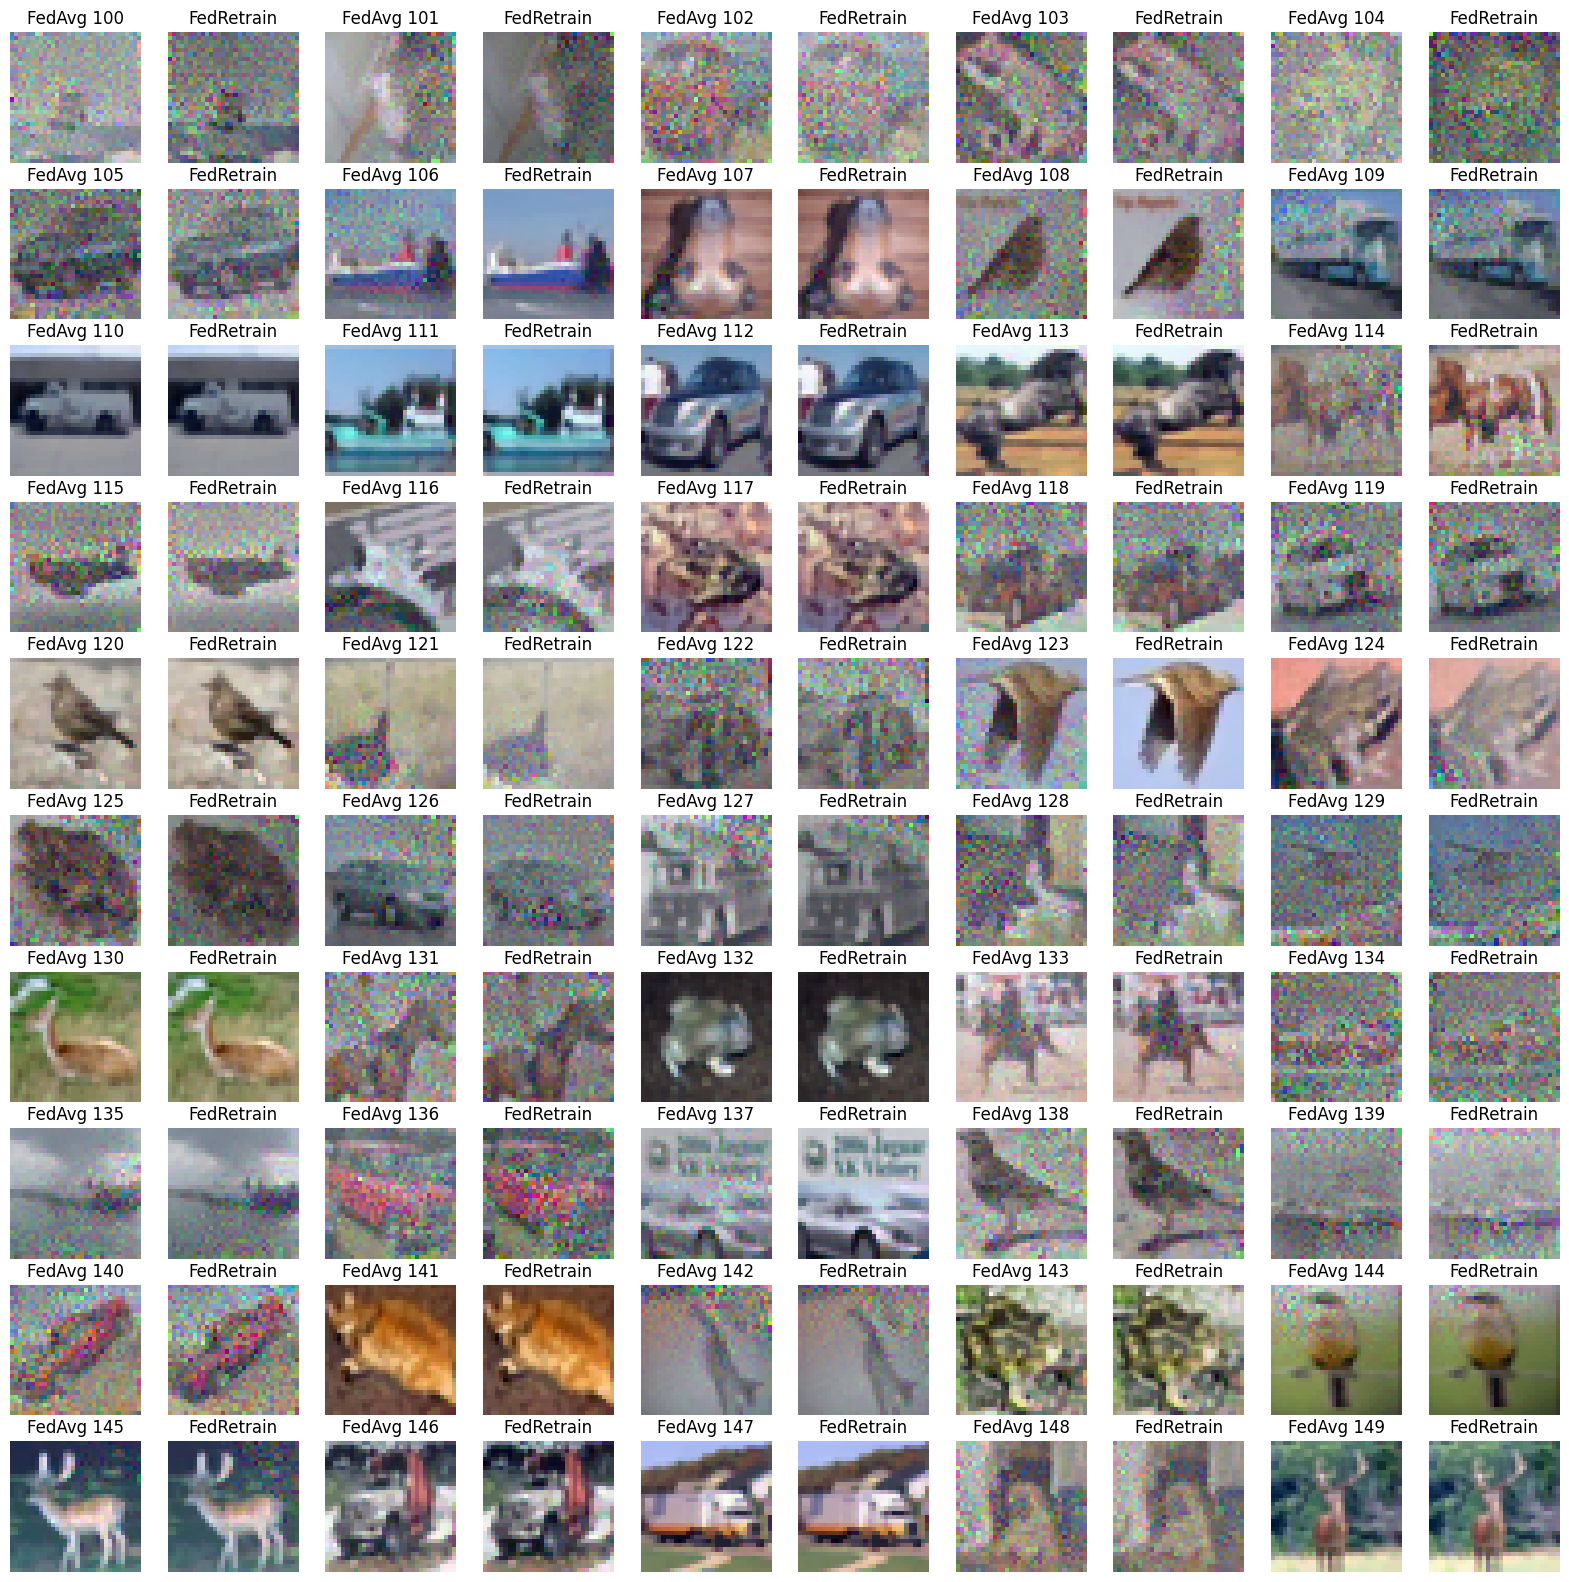

In [84]:
n_samples = 50
#9, 13, 40, 63, 100, 101
target_idxs = [9, 13, 26, 27, 35, 38, 39, 48, 80, 138, 183, 185, 189, 193, 194, 241, 251, 260, 284, 310, 335, 349]
target_idxs = [i for i in range(100, 100+n_samples)]
target_layer = "layer4.0.conv1"
original_imgs, reconstructed_imgs_fedavg, idxs_fedavg = dl_inversion(global_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=True, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_fedretrain = dl_inversion(retrained_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
# _, reconstructed_imgs_ga = dl_inversion(ga_unlearned_model, target_layer, dl_members, 50, 0.1, 1e-5, 
#                                                            stop_after_n_samples=n_samples, return_idxs=False)
# _, reconstructed_imgs_not = dl_inversion(not_unlearned_model, target_layer, dl_members, 50, 0.1, 1e-5, 
#                                                            stop_after_n_samples=n_samples, return_idxs=False)

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.reshape(-1, 2)
for i in range(n_samples):
    # axes[i, 0].set_title(f"Img: {idxs_fedavg[i]}")
    # axes[i, 0].imshow(format_img(original_imgs[i]))
    # axes[i, 1].set_title("FedAvg")
    # axes[i, 1].imshow(format_img(reconstructed_imgs_fedavg[i]))
    # axes[i, 2].set_title("FedRetrain")
    # axes[i, 2].imshow(format_img(reconstructed_imgs_fedretrain[i]))
    # axes[i, 3].set_title("Random")
    # # axes[i, 3].imshow(format_img(reconstructed_imgs_random[i]))
    # axes[i, 0].axis("off")
    # axes[i, 1].axis("off")
    # axes[i, 2].axis("off")
    # axes[i, 3].axis("off")

    axes[i, 0].set_title(f"FedAvg {idxs_fedavg[i]}")
    axes[i, 0].imshow(format_img(reconstructed_imgs_fedavg[i]))
    axes[i, 1].set_title("FedRetrain")
    axes[i, 1].imshow(format_img(reconstructed_imgs_fedretrain[i]))

    axes[i, 0].axis("off")
    axes[i, 1].axis("off")



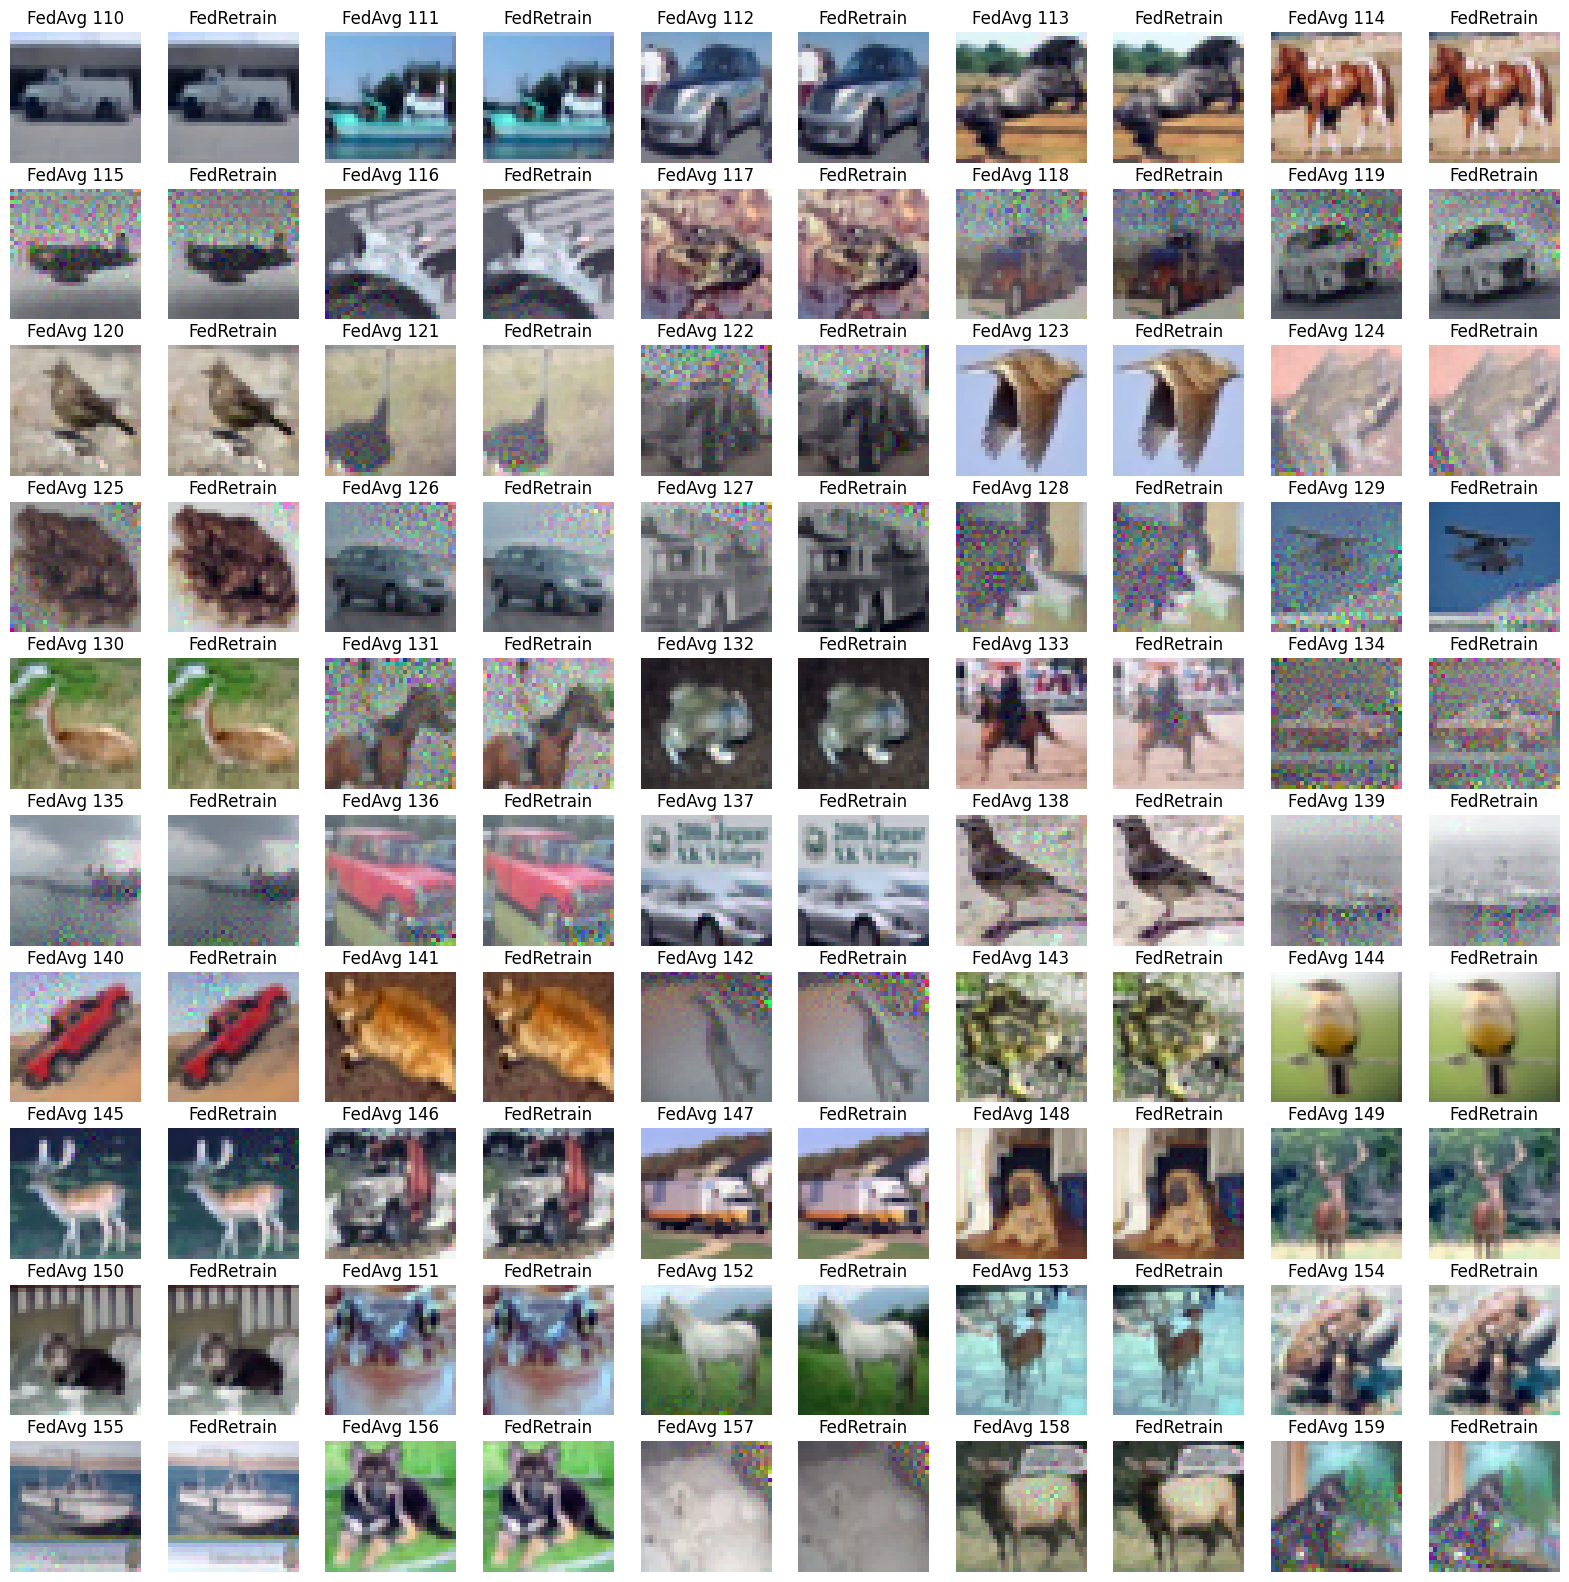

In [ ]:
n_samples = 50
#9
target_idxs = [9, 13, 26, 27, 35, 38, 39, 48, 80, 138, 183, 185, 189, 193, 194, 241, 251, 260, 284, 310, 335, 349]
target_idxs = [i for i in range(0, n_samples)]
target_layer = "layer4.0.conv1"
original_imgs, reconstructed_imgs_fedavg, idxs_fedavg = dl_inversion(global_model, target_layer, dl_members, 300, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=True, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_fedretrain = dl_inversion(retrained_model, target_layer, dl_members, 300, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
# _, reconstructed_imgs_ga = dl_inversion(ga_unlearned_model, target_layer, dl_members, 50, 0.1, 1e-5, 
#                                                            stop_after_n_samples=n_samples, return_idxs=False)
# _, reconstructed_imgs_not = dl_inversion(not_unlearned_model, target_layer, dl_members, 50, 0.1, 1e-5, 
#                                                            stop_after_n_samples=n_samples, return_idxs=False)

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.reshape(-1, 2)
for i in range(n_samples):
    # axes[i, 0].set_title(f"Img: {idxs_fedavg[i]}")
    # axes[i, 0].imshow(format_img(original_imgs[i]))
    # axes[i, 1].set_title("FedAvg")
    # axes[i, 1].imshow(format_img(reconstructed_imgs_fedavg[i]))
    # axes[i, 2].set_title("FedRetrain")
    # axes[i, 2].imshow(format_img(reconstructed_imgs_fedretrain[i]))
    # axes[i, 3].set_title("Random")
    # # axes[i, 3].imshow(format_img(reconstructed_imgs_random[i]))
    # axes[i, 0].axis("off")
    # axes[i, 1].axis("off")
    # axes[i, 2].axis("off")
    # axes[i, 3].axis("off")

    axes[i, 0].set_title(f"FedAvg {idxs_fedavg[i]}")
    axes[i, 0].imshow(format_img(reconstructed_imgs_fedavg[i]))
    axes[i, 1].set_title("FedRetrain")
    axes[i, 1].imshow(format_img(reconstructed_imgs_fedretrain[i]))

    axes[i, 0].axis("off")
    axes[i, 1].axis("off")



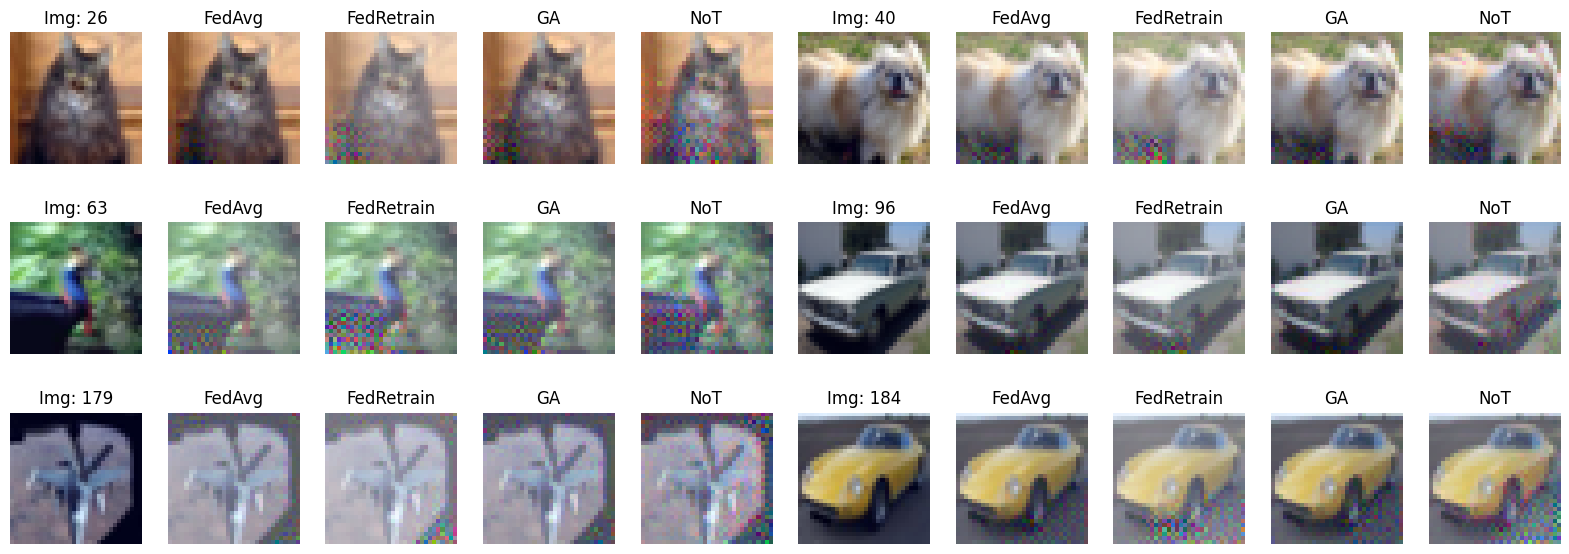

In [ ]:
target_idxs = [26, 40, 63, 96, 179, 184]
n_samples = len(target_idxs)

target_layer = "layer2"
original_imgs, reconstructed_imgs_fedavg, idxs_fedavg = dl_inversion(global_model, target_layer, dl_members, 120, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=True, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_fedretrain = dl_inversion(retrained_model, target_layer, dl_members, 120, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_ga = dl_inversion(ga_unlearned_model, target_layer, dl_members, 120, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_not = dl_inversion(not_unlearned_model, target_layer, dl_members, 120, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)

fig, axes = plt.subplots(int(np.ceil(n_samples/2)), 10, figsize=(20, 7))
axes = axes.reshape(-1, 5)
for i in range(n_samples):
    axes[i, 0].set_title(f"Img: {idxs_fedavg[i]}")
    axes[i, 0].imshow(format_img(original_imgs[i]))
    axes[i, 1].set_title("FedAvg")
    axes[i, 1].imshow(format_img(reconstructed_imgs_fedavg[i]))
    axes[i, 2].set_title("FedRetrain")
    axes[i, 2].imshow(format_img(reconstructed_imgs_fedretrain[i]))
    axes[i, 3].set_title("GA")
    axes[i, 3].imshow(format_img(reconstructed_imgs_ga[i]))
    axes[i, 4].set_title("NoT")
    axes[i, 4].imshow(format_img(reconstructed_imgs_not[i]))
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
    axes[i, 2].axis("off")
    axes[i, 3].axis("off")
    axes[i, 4].axis("off")


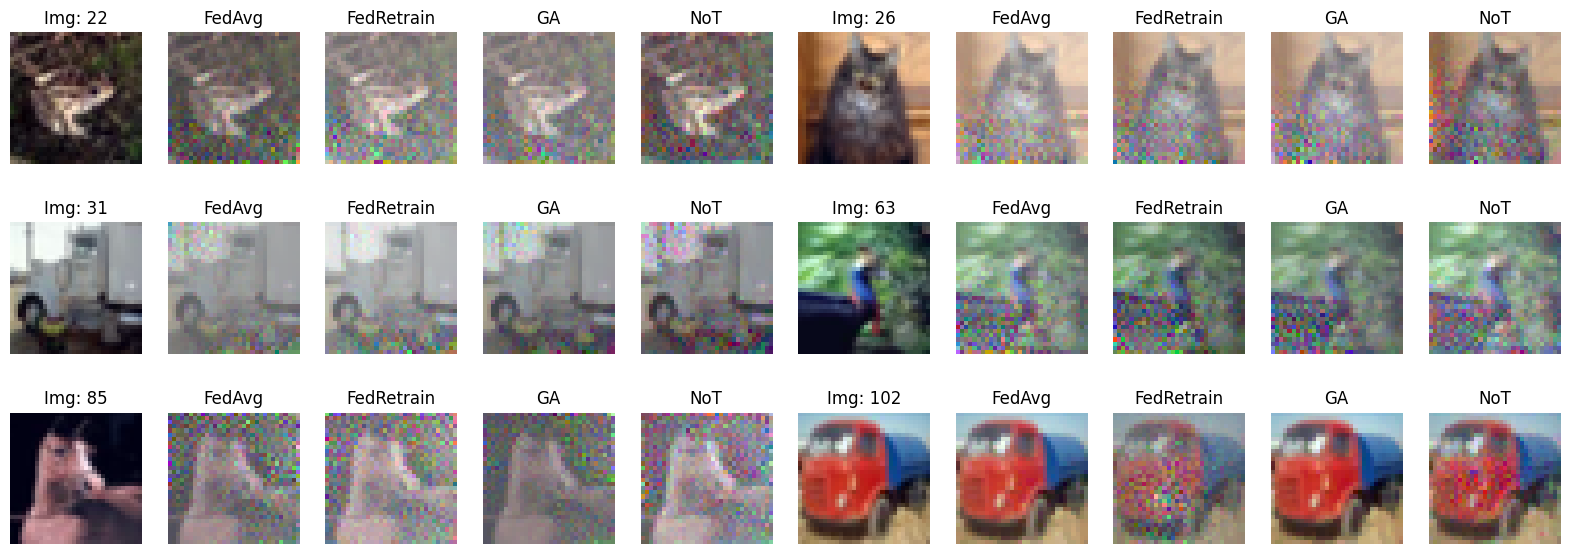

In [92]:
target_idxs = [22, 26, 31, 63, 85, 102]
n_samples = len(target_idxs)

target_layer = "layer3.1.conv1"
original_imgs, reconstructed_imgs_fedavg, idxs_fedavg = dl_inversion(global_model, target_layer, dl_members, 300, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=True, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_fedretrain = dl_inversion(retrained_model, target_layer, dl_members, 300, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_ga = dl_inversion(ga_unlearned_model, target_layer, dl_members, 300, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_not = dl_inversion(not_unlearned_model, target_layer, dl_members, 300, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)

fig, axes = plt.subplots(int(np.ceil(n_samples/2)), 10, figsize=(20, 7))
axes = axes.reshape(-1, 5)
for i in range(n_samples):
    axes[i, 0].set_title(f"Img: {idxs_fedavg[i]}")
    axes[i, 0].imshow(format_img(original_imgs[i]))
    axes[i, 1].set_title("FedAvg")
    axes[i, 1].imshow(format_img(reconstructed_imgs_fedavg[i]))
    axes[i, 2].set_title("FedRetrain")
    axes[i, 2].imshow(format_img(reconstructed_imgs_fedretrain[i]))
    axes[i, 3].set_title("GA")
    axes[i, 3].imshow(format_img(reconstructed_imgs_ga[i]))
    axes[i, 4].set_title("NoT")
    axes[i, 4].imshow(format_img(reconstructed_imgs_not[i]))
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
    axes[i, 2].axis("off")
    axes[i, 3].axis("off")
    axes[i, 4].axis("off")


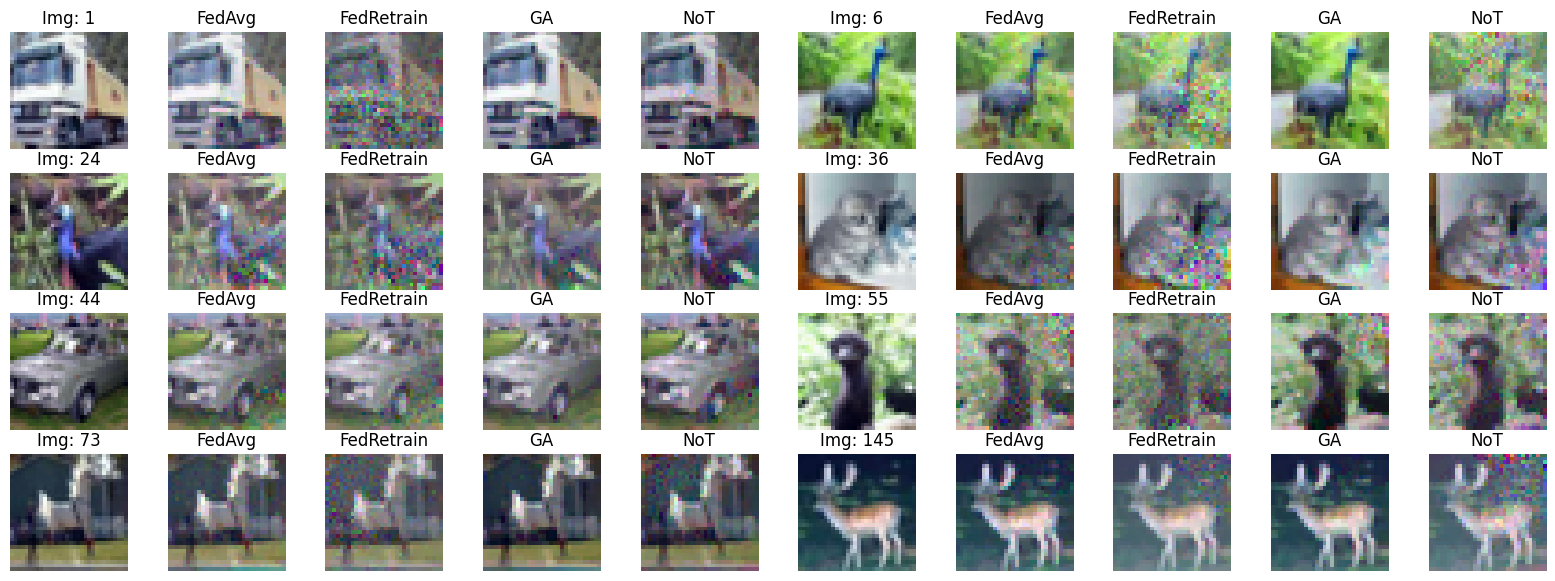

In [87]:
target_idxs = [1, 6, 24, 36, 44, 55, 73, 145]
n_samples = len(target_idxs)

target_layer = "layer4.0.conv1"
original_imgs, reconstructed_imgs_fedavg, idxs_fedavg = dl_inversion(global_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=True, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_fedretrain = dl_inversion(retrained_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_ga = dl_inversion(ga_unlearned_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_not = dl_inversion(not_unlearned_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)

fig, axes = plt.subplots(int(np.ceil(n_samples/2)), 10, figsize=(20, 7))
axes = axes.reshape(-1, 5)
for i in range(n_samples):
    axes[i, 0].set_title(f"Img: {idxs_fedavg[i]}")
    axes[i, 0].imshow(format_img(original_imgs[i]))
    axes[i, 1].set_title("FedAvg")
    axes[i, 1].imshow(format_img(reconstructed_imgs_fedavg[i]))
    axes[i, 2].set_title("FedRetrain")
    axes[i, 2].imshow(format_img(reconstructed_imgs_fedretrain[i]))
    axes[i, 3].set_title("GA")
    axes[i, 3].imshow(format_img(reconstructed_imgs_ga[i]))
    axes[i, 4].set_title("NoT")
    axes[i, 4].imshow(format_img(reconstructed_imgs_not[i]))
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
    axes[i, 2].axis("off")
    axes[i, 3].axis("off")
    axes[i, 4].axis("off")


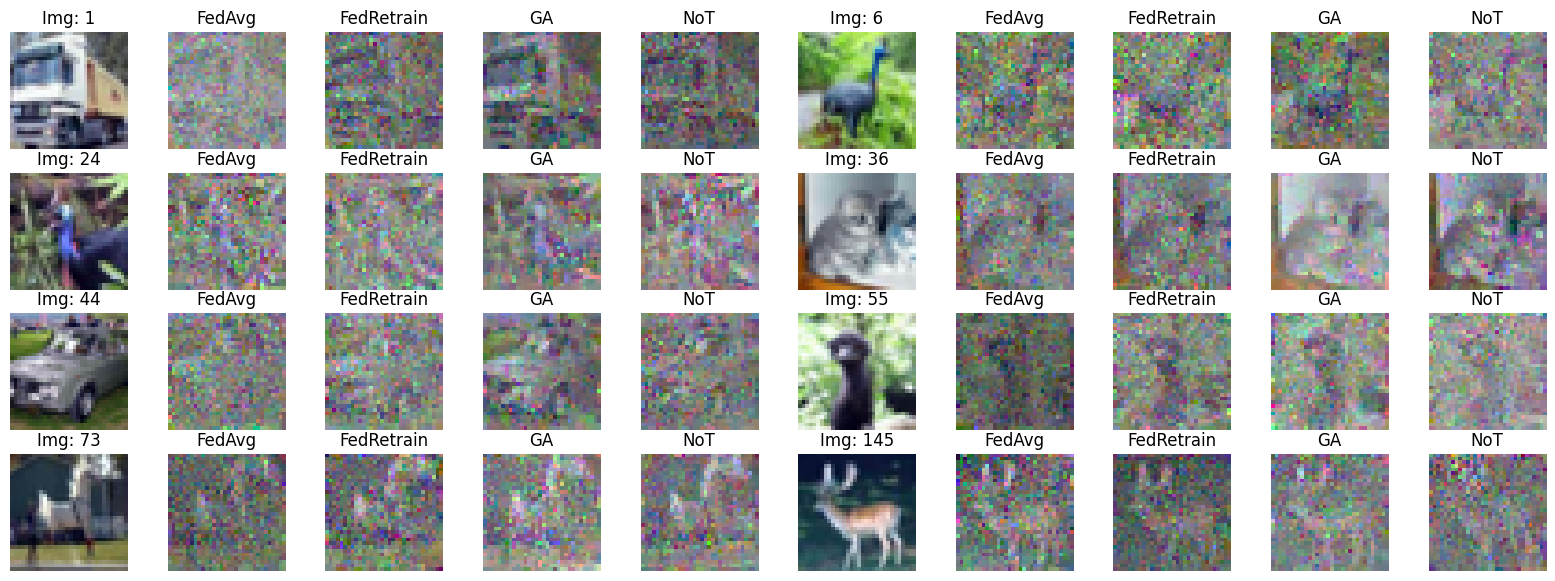

In [91]:
target_idxs = [1, 6, 24, 36, 44, 55, 73, 145]
n_samples = len(target_idxs)

target_layer = "layer4.0.conv2"
original_imgs, reconstructed_imgs_fedavg, idxs_fedavg = dl_inversion(global_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=True, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_fedretrain = dl_inversion(retrained_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_ga = dl_inversion(ga_unlearned_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)
_, reconstructed_imgs_not = dl_inversion(not_unlearned_model, target_layer, dl_members, 500, 0.1, 1e-5, 
                                                           stop_after_n_samples=n_samples, return_idxs=False, use_noise=False, samples_to_do=target_idxs)

fig, axes = plt.subplots(int(np.ceil(n_samples/2)), 10, figsize=(20, 7))
axes = axes.reshape(-1, 5)
for i in range(n_samples):
    axes[i, 0].set_title(f"Img: {idxs_fedavg[i]}")
    axes[i, 0].imshow(format_img(original_imgs[i]))
    axes[i, 1].set_title("FedAvg")
    axes[i, 1].imshow(format_img(reconstructed_imgs_fedavg[i]))
    axes[i, 2].set_title("FedRetrain")
    axes[i, 2].imshow(format_img(reconstructed_imgs_fedretrain[i]))
    axes[i, 3].set_title("GA")
    axes[i, 3].imshow(format_img(reconstructed_imgs_ga[i]))
    axes[i, 4].set_title("NoT")
    axes[i, 4].imshow(format_img(reconstructed_imgs_not[i]))
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
    axes[i, 2].axis("off")
    axes[i, 3].axis("off")
    axes[i, 4].axis("off")
